In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configure visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [4]:
# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='Price')

# Create a complete dataframe
df = X.copy()
df['Price'] = y

print(f"Dataset Loaded Successfully!")
print(f"  • Total Samples: {X.shape[0]}")
print(f"  • Total Features: {X.shape[1]}")
print(f"  • Target Variable: Price (in $100,000s)")


Dataset Loaded Successfully!
  • Total Samples: 20640
  • Total Features: 8
  • Target Variable: Price (in $100,000s)


In [5]:

print("\n--- First 10 Samples ---")
print(df.head(10))

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Basic Statistics ---")
print(df.describe())



--- First 10 Samples ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
5    

In [8]:

# Check for missing values
print("Missing Values")
missing_counts = df.isnull().sum()
if missing_counts.sum() == 0:
    print("No missing values detected!")
else:
    print(missing_counts[missing_counts > 0])


Missing Values
No missing values detected!


In [9]:
# Statistical summary
print("Statistical Summary ")
print(f"Price Range: ${y.min()*100000:,.0f} - ${y.max()*100000:,.0f}")
print(f"Mean Price: ${y.mean()*100000:,.0f}")
print(f"Median Price: ${y.median()*100000:,.0f}")
print(f"Standard Deviation: ${y.std()*100000:,.0f}")


Statistical Summary 
Price Range: $14,999 - $500,001
Mean Price: $206,856
Median Price: $179,700
Standard Deviation: $115,396


In [10]:

# Correlation analysis
print("Correlation with Target Price")
correlation = df.corr()['Price'].sort_values(ascending=False)
print(correlation)

Correlation with Target Price
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


✓ EDA Visualizations saved


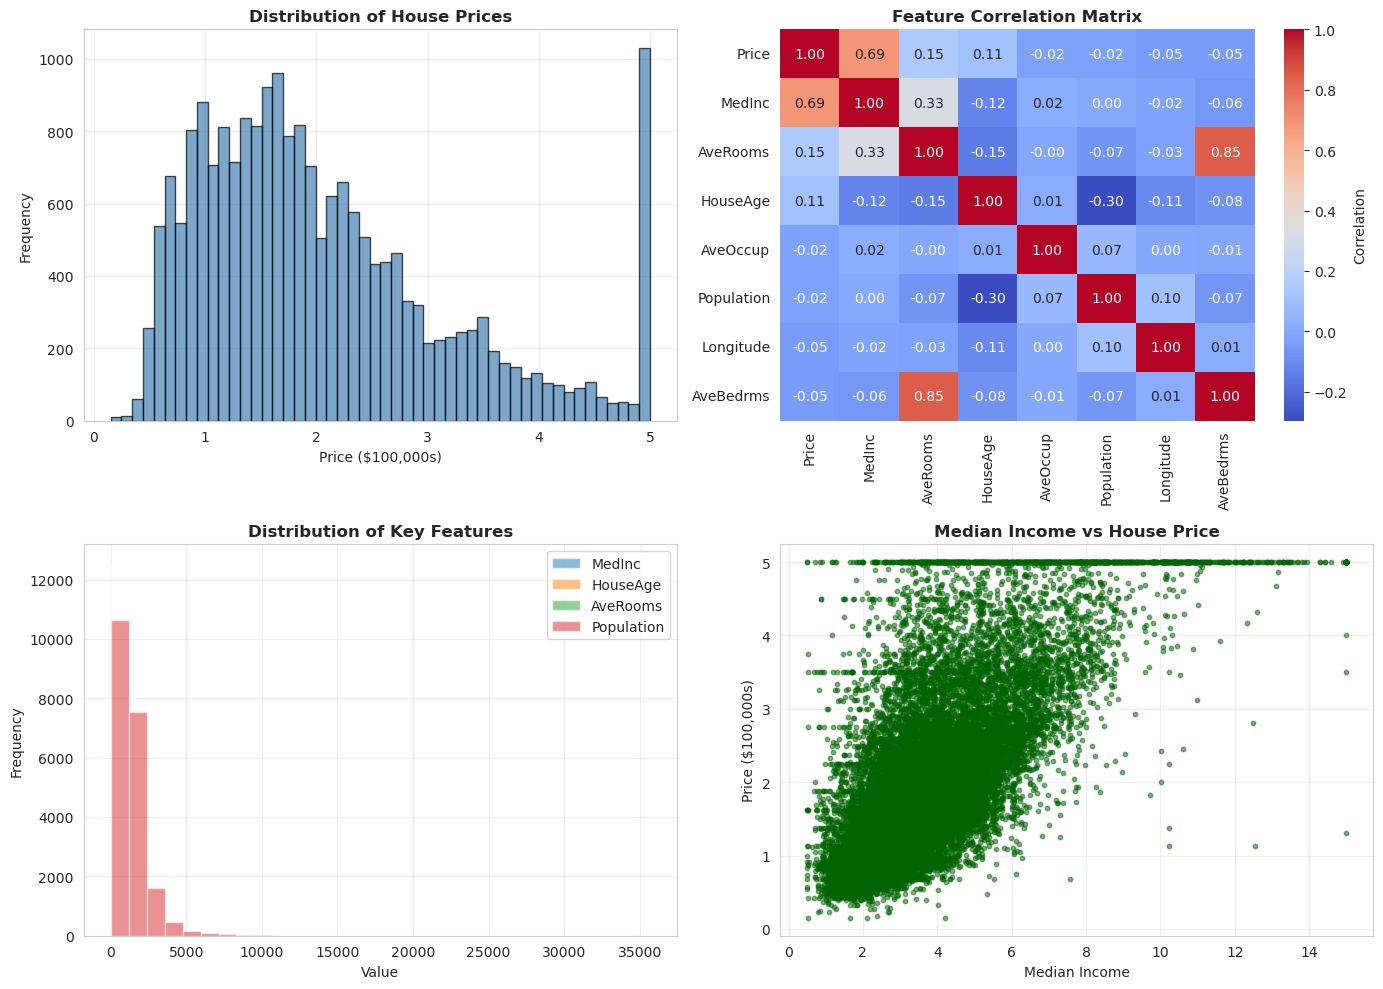

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable Distribution
ax1 = axes[0, 0]
ax1.hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of House Prices', fontweight='bold', fontsize=12)
ax1.set_xlabel('Price ($100,000s)')
ax1.set_ylabel('Frequency')
ax1.grid(alpha=0.3)

# 2. Correlation Heatmap
ax2 = axes[0, 1]
top_features = correlation.index[0:8]
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, cbar_kws={'label': 'Correlation'})
ax2.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)

# 3. Feature Distributions (selected features)
ax3 = axes[1, 0]
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
for feature in features_to_plot:
    ax3.hist(X[feature], alpha=0.5, label=feature, bins=30)
ax3.set_title('Distribution of Key Features', fontweight='bold', fontsize=12)
ax3.set_xlabel('Value')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Scatter plot: Income vs Price (strongest correlation)
ax4 = axes[1, 1]
ax4.scatter(X['MedInc'], y, alpha=0.5, s=10, color='darkgreen')
ax4.set_title('Median Income vs House Price', fontweight='bold', fontsize=12)
ax4.set_xlabel('Median Income')
ax4.set_ylabel('Price ($100,000s)')
ax4.grid(alpha=0.3)

plt.tight_layout()
print("✓ EDA Visualizations saved")
plt.show()


In [12]:
# Features and target
X = df.drop('Price', axis=1)
y = df['Price']

print(f"Features extracted: {X.shape}")
print(f"Target extracted: {y.shape}")

Features extracted: (20640, 8)
Target extracted: (20640,)


In [14]:
# Check for missing values and handle them
print("Handling Missing Values")
if X.isnull().sum().sum() == 0:
    print("No missing values found in features!")
else:
    print("Filling missing values with median...")
    X = X.fillna(X.median())
    print("Missing values handled!")


Handling Missing Values
No missing values found in features!


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Training set features: {X_train.shape[1]}")


Training set size: 16512 (80.0%)
Testing set size: 4128 (20.0%)
Training set features: 8


In [16]:
# Create a pipeline with preprocessing and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Feature scaling
    ('regressor', LinearRegression())  # Step 2: Linear Regression model
])

In [17]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [19]:
# Predictions on training and test sets
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

print(f"Predictions made on {len(y_test)} test samples")


Predictions made on 4128 test samples


In [21]:


# Create comparison dataframe for test set
predictions_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_test_pred,
    'Difference': y_test.values - y_test_pred,
    'Abs_Error': np.abs(y_test.values - y_test_pred)
})

print("Sample Predictions (First 10 Test Samples)")
print(predictions_df.head(10).to_string(index=False))


Sample Predictions (First 10 Test Samples)
 Actual_Price  Predicted_Price  Difference  Abs_Error
      0.47700         0.719123   -0.242123   0.242123
      0.45800         1.764017   -1.306017   1.306017
      5.00001         2.709659    2.290351   2.290351
      2.18600         2.838926   -0.652926   0.652926
      2.78000         2.604657    0.175343   0.175343
      1.58700         2.011754   -0.424754   0.424754
      1.98200         2.645500   -0.663500   0.663500
      1.57500         2.168755   -0.593755   0.593755
      3.40000         2.740746    0.659254   0.659254
      4.46600         3.915615    0.550385   0.550385


In [22]:

# Calculate metrics for training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)


In [24]:

print("TRAINING SET METRICS ---")
print(f"  MAE:  ${train_mae*100000:,.2f}")
print(f"  MSE:  {train_mse:.4f}")
print(f"  RMSE: ${train_rmse*100000:,.2f}")
print(f"  R²:   {train_r2:.4f}")

print("TEST SET METRICS ---")
print(f"  MAE:  ${test_mae*100000:,.2f}")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: ${test_rmse*100000:,.2f}")
print(f"  R²:   {test_r2:.4f}")


TRAINING SET METRICS ---
  MAE:  $52,862.84
  MSE:  0.5179
  RMSE: $71,967.57
  R²:   0.6126
TEST SET METRICS ---
  MAE:  $53,320.01
  MSE:  0.5559
  RMSE: $74,558.14
  R²:   0.5758


In [26]:
print("Performing 5-Fold Cross-Validation")
cv_scores_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
cv_scores_mae = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"  R² Scores: {[f'{score:.4f}' for score in cv_scores_r2]}")
print(f"  Mean R²: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std():.4f})")
print(f"\n  MAE Scores: {[f'${score*100000:,.2f}' for score in cv_scores_mae]}")
print(f"  Mean MAE: ${cv_scores_mae.mean()*100000:,.2f} (+/- ${cv_scores_mae.std()*100000:,.2f})")


Performing 5-Fold Cross-Validation
  R² Scores: ['0.6201', '0.6130', '0.6134', '0.6107', '0.6002']
  Mean R²: 0.6115 (+/- 0.0065)

  MAE Scores: ['$53,113.06', '$52,675.12', '$52,419.84', '$52,479.37', '$53,843.44']
  Mean MAE: $52,906.17 (+/- $527.89)


In [27]:
# Extract coefficients from trained model
regressor = pipeline.named_steps['regressor']
coefficients = regressor.coef_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Coefficients (Impact on Price)")
print(feature_importance_df.to_string(index=False))

print(f"\nIntercept (Bias): {regressor.intercept_:.4f}")


Feature Coefficients (Impact on Price)
   Feature  Coefficient  Abs_Coefficient
  Latitude    -0.896929         0.896929
 Longitude    -0.869842         0.869842
    MedInc     0.854383         0.854383
 AveBedrms     0.339259         0.339259
  AveRooms    -0.294410         0.294410
  HouseAge     0.122546         0.122546
  AveOccup    -0.040829         0.040829
Population    -0.002308         0.002308

Intercept (Bias): 2.0719


✓ Prediction comparison visualizations saved


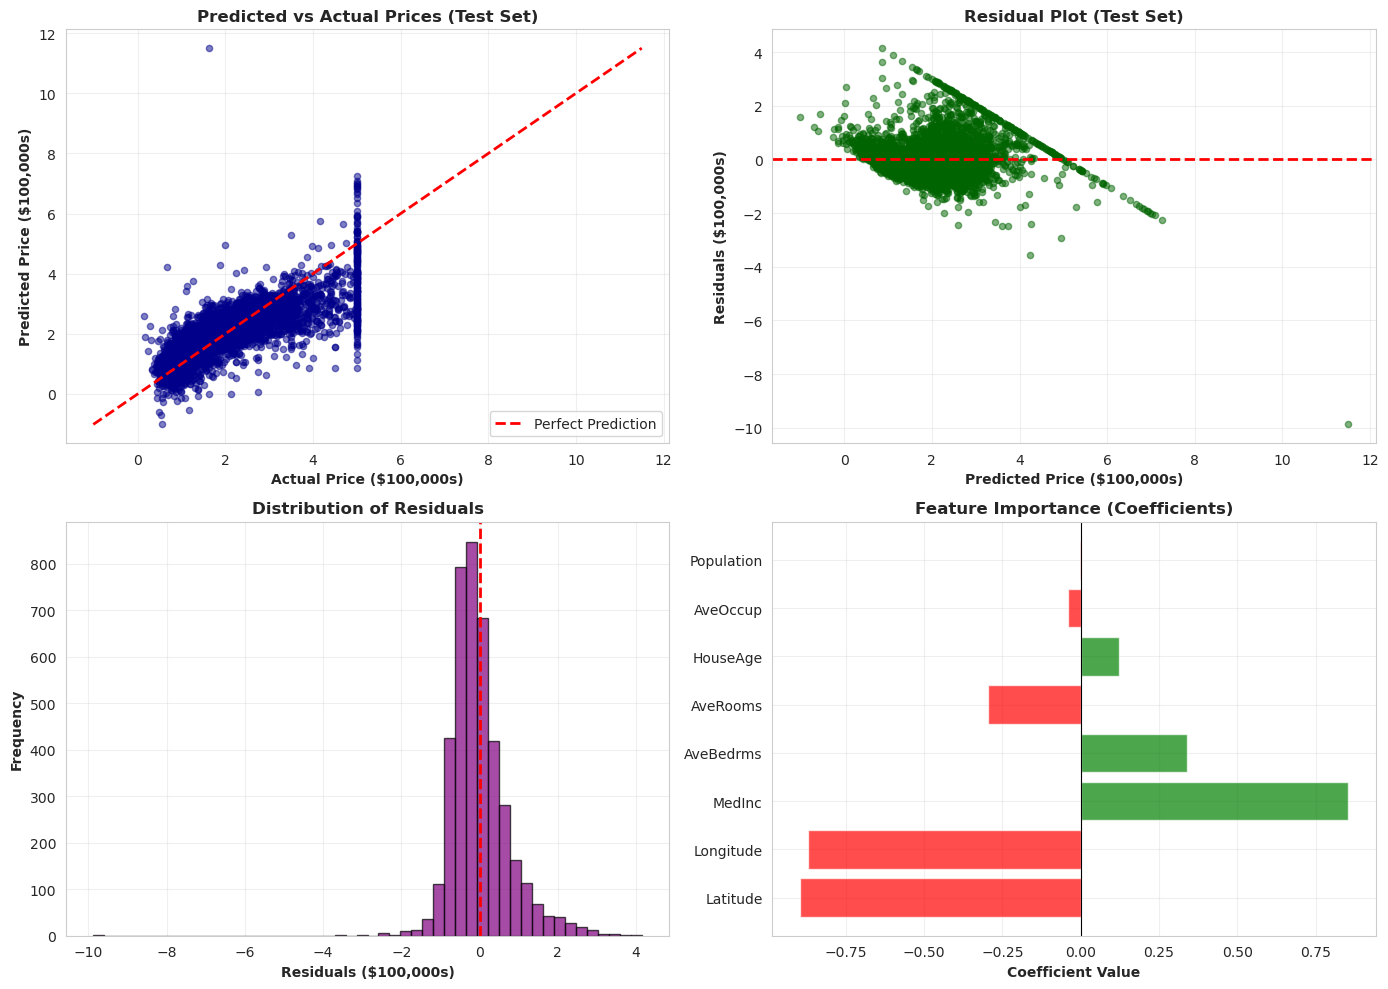

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual (Test Set)
ax1 = axes[0, 0]
ax1.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='darkblue')
# Add perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Price ($100,000s)', fontweight='bold')
ax1.set_ylabel('Predicted Price ($100,000s)', fontweight='bold')
ax1.set_title('Predicted vs Actual Prices (Test Set)', fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Residuals Plot
ax2 = axes[0, 1]
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.5, s=20, color='darkgreen')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Price ($100,000s)', fontweight='bold')
ax2.set_ylabel('Residuals ($100,000s)', fontweight='bold')
ax2.set_title('Residual Plot (Test Set)', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)

# 3. Residuals Distribution
ax3 = axes[1, 0]
ax3.hist(residuals, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuals ($100,000s)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Distribution of Residuals', fontweight='bold', fontsize=12)
ax3.grid(alpha=0.3)

# 4. Feature Importance Plot
ax4 = axes[1, 1]
top_features = feature_importance_df.head(8)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
ax4.barh(top_features['Feature'], top_features['Coefficient'], color=colors, alpha=0.7)
ax4.set_xlabel('Coefficient Value', fontweight='bold')
ax4.set_title('Feature Importance (Coefficients)', fontweight='bold', fontsize=12)
ax4.axvline(x=0, color='black', linestyle='-', lw=0.8)
ax4.grid(alpha=0.3)

plt.tight_layout()
print("✓ Prediction comparison visualizations saved")
plt.show()

Regression line visualizations saved


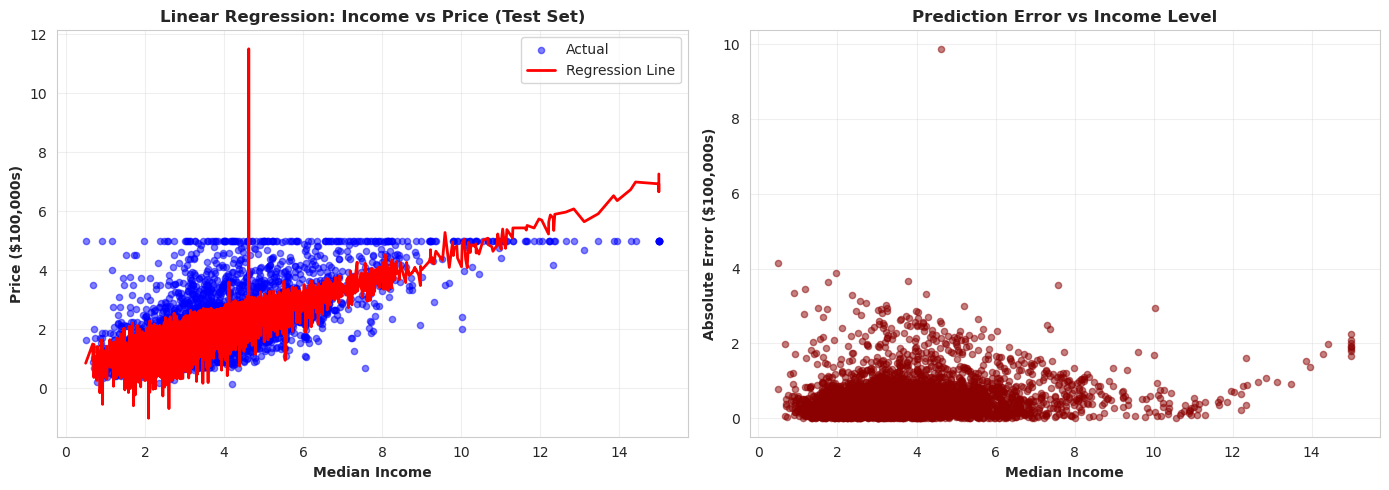

In [29]:
# Create visualization for one feature (MedInc - strongest correlation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Regression line for strongest feature
ax1 = axes[0]
# Sort data for line plot
sorted_indices = np.argsort(X_test['MedInc'].values)
X_sorted = X_test.iloc[sorted_indices]
y_test_sorted = y_test.iloc[sorted_indices]
y_pred_sorted = y_test_pred[sorted_indices]

ax1.scatter(X_sorted['MedInc'], y_test_sorted, alpha=0.5, s=20, label='Actual', color='blue')
ax1.plot(X_sorted['MedInc'], y_pred_sorted, color='red', linewidth=2, label='Regression Line')
ax1.set_xlabel('Median Income', fontweight='bold')
ax1.set_ylabel('Price ($100,000s)', fontweight='bold')
ax1.set_title('Linear Regression: Income vs Price (Test Set)', fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Error Distribution by Income Level
ax2 = axes[1]
errors = predictions_df['Abs_Error']
ax2.scatter(X_test['MedInc'], errors, alpha=0.5, s=20, color='darkred')
ax2.set_xlabel('Median Income', fontweight='bold')
ax2.set_ylabel('Absolute Error ($100,000s)', fontweight='bold')
ax2.set_title('Prediction Error vs Income Level', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
print("Regression line visualizations saved")
plt.show()

In [30]:
# Save the pipeline
model_filename = 'california_housing_pipeline.pkl'
joblib.dump(pipeline, model_filename)
print(f"Model saved as '{model_filename}'")


Model saved as 'california_housing_pipeline.pkl'


In [31]:

# Load the pipeline
loaded_pipeline = joblib.load(model_filename)

In [32]:

# Verify loaded model makes same predictions
y_loaded_pred = loaded_pipeline.predict(X_test[:5])
y_original_pred = pipeline.predict(X_test[:5])

print(f"Predictions match: {np.allclose(y_original_pred, y_loaded_pred)}")


Predictions match: True


In [33]:
# Create sample data (same feature structure as training data)
custom_data = pd.DataFrame({
    'MedInc': [5.0, 8.0, 3.5],
    'HouseAge': [20.0, 50.0, 15.0],
    'AveRooms': [5.0, 6.5, 4.5],
    'AveBedrms': [1.5, 2.0, 1.2],
    'Population': [1000.0, 2000.0, 800.0],
    'AveOccup': [3.0, 3.5, 2.8],
    'Latitude': [34.0, 38.0, 35.0],
    'Longitude': [-118.0, -122.0, -117.0]
})


In [37]:
 # Make predictions
custom_predictions = pipeline.predict(custom_data)

In [38]:
custom_predictions

array([2.86468118, 4.76089061, 1.11737637])

In [ ]:
print("Predictions for Custom Data")
for idx, (_, row) in enumerate(custom_data.iterrows()):
    price = custom_predictions[idx]
    print(f"  Sample {idx+1}: Median Income ${row['MedInc']*10000:,.0f} → "
          f"Predicted Price ${price*100000:,.0f}")

Predictions for Custom Data
  Sample 1: Median Income $50,000 → Predicted Price $286,468
  Sample 2: Median Income $80,000 → Predicted Price $476,089
  Sample 3: Median Income $35,000 → Predicted Price $111,738


In [4]:
import datetime
today = datetime.datetime.today()
print(f'Today is day: {today}')

Today is day: 2026-04-01 23:50:21.698991
